# Базовый блок. Обработка текстов с помощью нейронных сетей. ДЗ Lite

## Классификация писателей — 9 моделей

**Параметры предобработки:**
- Размер словаря (`VOCAB_SIZE`): **15 000**
- Ширина окна (`WIN_SIZE`): **1 000**
- Шаг окна (`WIN_HOP`): **100**

Создаём 9 нейросетей:
- 4 модели Bag of Words
- 5 моделей Embedding + Flatten

## Импорт библиотек

In [ ]:
# Работа с массивами данных
import numpy as np

# Функции-утилиты для работы с категориальными данными
from tensorflow.keras import utils

# Класс для конструирования последовательной модели нейронной сети
from tensorflow.keras.models import Sequential

# Основные слои
from tensorflow.keras.layers import Dense, Dropout, SpatialDropout1D, BatchNormalization, Embedding, Flatten, Activation

# Токенизатор для преобразования текстов в последовательности
from tensorflow.keras.preprocessing.text import Tokenizer

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Загрузка датасетов из облака google
import gdown

# Функции операционной системы
import os

# Работа со временем
import time

# Регулярные выражения
import re

# Запись в файлы и чтение из файлов структур данных Python
import pickle

# Отрисовка графиков
import matplotlib.pyplot as plt

%matplotlib inline

## Загрузка датасета и подготовка данных

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l7/writers.zip', None, quiet=True)

'writers.zip'

In [ ]:
# Распаковка архива в папку writers
!unzip -qo writers.zip -d writers/

# Просмотр содержимого папки
!ls writers

'(Булгаков) Обучающая_5 вместе.txt'
'(Булгаков) Тестовая_2 вместе.txt'
'(Клиффорд_Саймак) Обучающая_5 вместе.txt'
'(Клиффорд_Саймак) Тестовая_2 вместе.txt'
'(Макс Фрай) Обучающая_5 вместе.txt'
'(Макс Фрай) Тестовая_2 вместе.txt'
'(О. Генри) Обучающая_50 вместе.txt'
'(О. Генри) Тестовая_20 вместе.txt'
'(Рэй Брэдберри) Обучающая_22 вместе.txt'
'(Рэй Брэдберри) Тестовая_8 вместе.txt'
'(Стругацкие) Обучающая_5 вместе.txt'
'(Стругацкие) Тестовая_2 вместе.txt'


In [ ]:
# Настройка констант для загрузки данных
FILE_DIR  = 'writers'
SIG_TRAIN = 'обучающая'
SIG_TEST  = 'тестовая'

In [ ]:
# Загрузка датасета
CLASS_LIST = []
text_train = []
text_test = []

for file_name in os.listdir(FILE_DIR):
    m = re.match(r'\((.+)\) (\S+)_', file_name)
    if m:
        class_name = m[1]
        subset_name = m[2].lower()
        is_train = SIG_TRAIN in subset_name
        is_test = SIG_TEST in subset_name

        if is_train or is_test:
            if class_name not in CLASS_LIST:
                print(f'Добавление класса "{class_name}"')
                CLASS_LIST.append(class_name)
                text_train.append('')
                text_test.append('')

            cls = CLASS_LIST.index(class_name)
            print(f'Добавление файла "{file_name}" в класс "{CLASS_LIST[cls]}", {subset_name} выборка.')
            with open(f'{FILE_DIR}/{file_name}', 'r') as f:
                text = f.read()
            subset = text_train if is_train else text_test
            subset[cls] += ' ' + text.replace('\n', ' ')

CLASS_COUNT = len(CLASS_LIST)
print(f'\nКлассов: {CLASS_COUNT}')

Добавление класса "Макс Фрай"
Добавление файла "(Макс Фрай) Тестовая_2 вместе.txt" в класс "Макс Фрай", тестовая выборка.
Добавление класса "О. Генри"
Добавление файла "(О. Генри) Тестовая_20 вместе.txt" в класс "О. Генри", тестовая выборка.
Добавление класса "Рэй Брэдберри"
Добавление файла "(Рэй Брэдберри) Тестовая_8 вместе.txt" в класс "Рэй Брэдберри", тестовая выборка.
Добавление файла "(О. Генри) Обучающая_50 вместе.txt" в класс "О. Генри", обучающая выборка.
Добавление класса "Клиффорд_Саймак"
Добавление файла "(Клиффорд_Саймак) Тестовая_2 вместе.txt" в класс "Клиффорд_Саймак", тестовая выборка.
Добавление файла "(Рэй Брэдберри) Обучающая_22 вместе.txt" в класс "Рэй Брэдберри", обучающая выборка.
Добавление класса "Стругацкие"
Добавление файла "(Стругацкие) Обучающая_5 вместе.txt" в класс "Стругацкие", обучающая выборка.
Добавление файла "(Клиффорд_Саймак) Обучающая_5 вместе.txt" в класс "Клиффорд_Саймак", обучающая выборка.
Добавление класса "Булгаков"
Добавление файла "(Булгако

## Параметры преобразования

In [ ]:
# Задание параметров преобразования
VOCAB_SIZE = 15000
WIN_SIZE   = 1000
WIN_HOP    = 100

## Токенизация и построение частотного словаря

In [ ]:
tokenizer = Tokenizer(num_words=VOCAB_SIZE,
                          filters='!"#$%&()*+,-–—./…:;<=>?@[\\]^_`{|}~«»\t\n\xa0\ufeff',
                          lower=True, split=' ',
                          oov_token='неизвестное_слово',
                          char_level=False)
tokenizer.fit_on_texts(text_train)
items = list(tokenizer.word_index.items())

print('Размер словаря:', len(items))

Размер словаря: 133070


In [ ]:
seq_train = tokenizer.texts_to_sequences(text_train)
seq_test = tokenizer.texts_to_sequences(text_test)

print(f"Первые 10 слов в виде оригинального текста: {text_train[0][:68]}")
print(f"Первые 10 слов из первого текста обучающей выборки: {seq_train[0][:10]}")
print(f"Первые 10 слов в виде оригинального текста: {text_test[0][:69]}")
print(f"Первые 10 слов из первого текста тестовой выборки: {seq_test[0][:10]}")

Первые 10 слов в виде оригинального текста:  ﻿Власть несбывшегося   – С тех пор как меня угораздило побывать в э
Первые 10 слов из первого текста обучающей выборки: [1496, 1, 8, 282, 236, 11, 24, 9662, 5988, 3]
Первые 10 слов в виде оригинального текста:  ﻿Слишком много кошмаров    Когда балансируешь над пропастью на узкой
Первые 10 слов из первого текста тестовой выборки: [170, 191, 1, 40, 1, 133, 1, 7, 5854, 1]


## Формирование обучающей и тестовой выборок

In [ ]:
def split_sequence(sequence, win_size, hop):
    return [sequence[i:i + win_size] for i in range(0, len(sequence) - win_size + 1, hop)]

def vectorize_sequence(seq_list, win_size, hop):
    class_count = len(seq_list)
    x, y = [], []
    for cls in range(class_count):
        vectors = split_sequence(seq_list[cls], win_size, hop)
        x += vectors
        y += [utils.to_categorical(cls, class_count)] * len(vectors)
    return np.array(x), np.array(y)

In [ ]:
x_train, y_train = vectorize_sequence(seq_train, WIN_SIZE, WIN_HOP)
x_test, y_test = vectorize_sequence(seq_test, WIN_SIZE, WIN_HOP)
print(f'Размер обучающей выборки: {x_train.shape}, {y_train.shape}')
print(f'Размер тестовой выборки: {x_test.shape}, {y_test.shape}')

Размер обучающей выборки: (17640, 1000), (17640, 6)
Размер тестовой выборки: (6686, 1000), (6686, 6)


In [ ]:
x_train_01 = tokenizer.sequences_to_matrix(x_train.tolist())
x_test_01 = tokenizer.sequences_to_matrix(x_test.tolist())
# Вывод формы обучающей выборки в виде разреженной матрицы Bag of Words
print(x_train_01.shape)
# Вывод фрагмента отрезка обучающего текста в виде Bag of Words
print(x_train_01[0][0:100])

(17640, 15000)
[0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1.
 1. 1. 1. 1. 1. 0. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 0. 0. 1. 1. 1. 1.
 1. 1. 1. 1. 0. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 0. 1. 0. 1. 1. 1. 0. 1.
 1. 0. 1. 0.]


## Сервисные функции

In [ ]:
def compile_train_model(model, x_train, y_train, x_val, y_val,
                        optimizer='adam', epochs=20, batch_size=128, figsize=(20, 5)):
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    model.summary()

    history = model.fit(x_train, y_train,
                        epochs=epochs,
                        batch_size=batch_size,
                        validation_data=(x_val, y_val))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=figsize)
    fig.suptitle('График процесса обучения модели')
    ax1.plot(history.history['accuracy'], label='Обучающая выборка')
    ax1.plot(history.history['val_accuracy'], label='Проверочная выборка')
    ax1.set_xlabel('Эпоха обучения')
    ax1.set_ylabel('Доля верных ответов')
    ax1.legend()

    ax2.plot(history.history['loss'], label='Обучающая выборка')
    ax2.plot(history.history['val_loss'], label='Проверочная выборка')
    ax2.set_xlabel('Эпоха обучения')
    ax2.set_ylabel('Ошибка')
    ax2.legend()
    plt.show()


def eval_model(model, x, y_true, class_labels=[], cm_round=3, title='', figsize=(10, 10)):
    y_pred = model.predict(x)
    cm = confusion_matrix(np.argmax(y_true, axis=1), np.argmax(y_pred, axis=1), normalize='true')
    cm = np.around(cm, cm_round)

    fig, ax = plt.subplots(figsize=figsize)
    ax.set_title(f'Нейросеть {title}: матрица ошибок', fontsize=18)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)
    disp.plot(ax=ax)
    plt.gca().images[-1].colorbar.remove()
    plt.xlabel('Предсказанные классы', fontsize=16)
    plt.ylabel('Верные классы', fontsize=16)
    fig.autofmt_xdate(rotation=45)
    plt.show()

    print('-'*100)
    print(f'Нейросеть: {title}')
    for cls in range(len(class_labels)):
        cls_pred = np.argmax(cm[cls])
        msg = 'ВЕРНО :-)' if cls_pred == cls else 'НЕВЕРНО :-('
        print('Класс: {:<20} {:3.0f}% сеть отнесла к классу {:<20} - {}'.format(
            class_labels[cls], 100. * cm[cls, cls_pred], class_labels[cls_pred], msg))
    accuracy = 100. * cm.diagonal().mean()
    print('\nСредняя точность распознавания: {:3.0f}%'.format(accuracy))
    return accuracy


def compile_train_eval_model(model, x_train, y_train, x_test, y_test,
                             class_labels=CLASS_LIST, title='', optimizer='adam',
                             epochs=20, batch_size=128, graph_size=(20, 5), cm_size=(10, 10)):
    compile_train_model(model, x_train, y_train, x_test, y_test,
                        optimizer=optimizer, epochs=epochs, batch_size=batch_size, figsize=graph_size)
    accuracy = eval_model(model, x_test, y_test, class_labels=class_labels, title=title, figsize=cm_size)
    return accuracy

results = {}

# 9 моделей с различными гиперпараметрами

## Модель 1: BoW + Dense(200) + Dropout(0.25)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 200)            │     3,000,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,206 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,002,206 (11.45 MB)

 Trainable params: 3,001,806 (11.45 MB)

 Non-trainable params: 400 (1.56 KB)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 38ms/step - accuracy: 0.9847 - loss: 0.0500 - val_accuracy: 0.8708 - val_loss: 0.4178
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 4.5788e-04 - val_accuracy: 0.8883 - val_loss: 0.3399
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 2.2351e-04 - val_accuracy: 0.8926 - val_loss: 0.3207
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 1.5363e-04 - val_accuracy: 0.8925 - val_loss: 0.3188
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 1.0855e-04 - val_accuracy: 0.8941 - val_loss: 0.3119
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 8.0138e-05 - val_accuracy: 0.8955 - val_loss: 0.3103
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 6.4887e-05 - val_accuracy: 0.8958 - val_loss: 0.3084
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss:

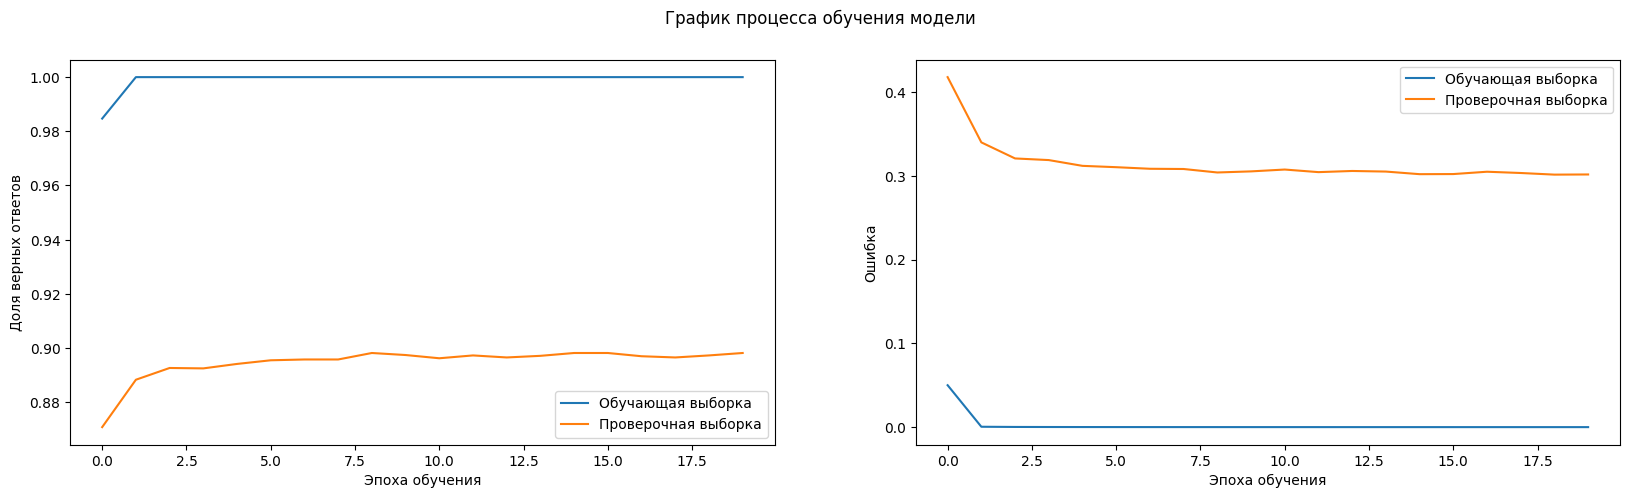

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


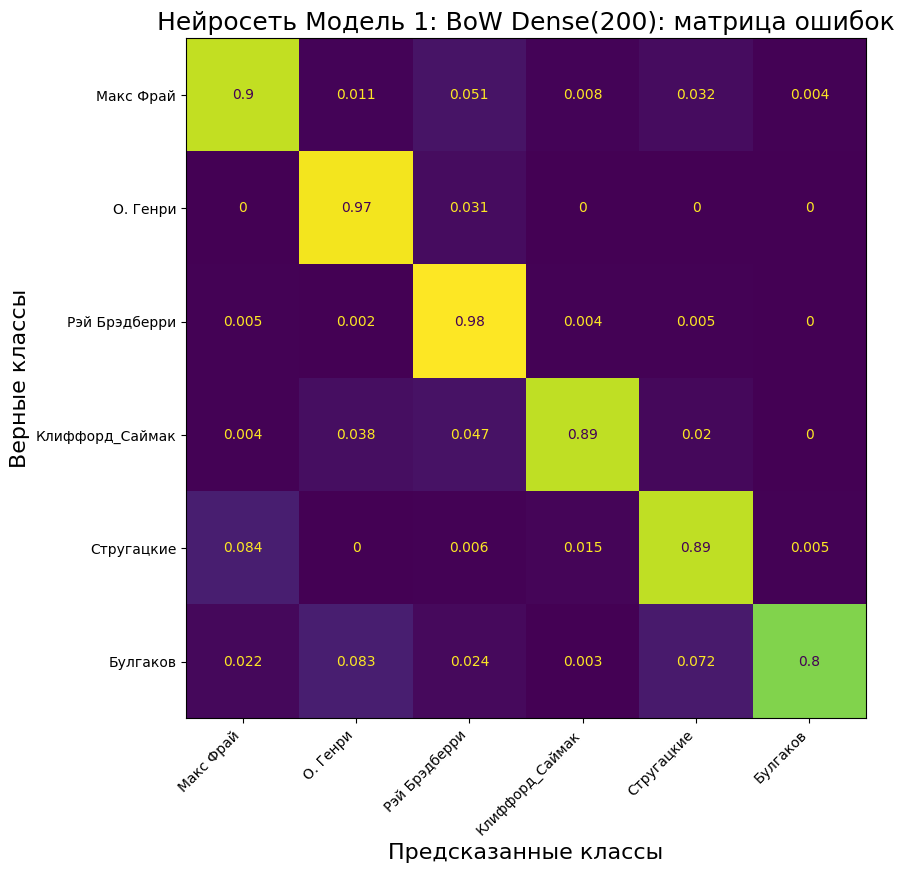

----------------------------------------------------------------------------------------------------
Нейросеть: Модель 1: BoW Dense(200)
Класс: Макс Фрай             90% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              97% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         98% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       89% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            89% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              80% сеть отнесла к классу Булгаков             - ВЕРНО :-)

Средняя точность распознавания:  90%


In [ ]:
model_1 = Sequential()
model_1.add(Dense(200, input_dim=VOCAB_SIZE, activation='relu'))
model_1.add(Dropout(0.25))
model_1.add(BatchNormalization())
model_1.add(Dense(CLASS_COUNT, activation='softmax'))

acc_1 = compile_train_eval_model(model_1, x_train_01, y_train, x_test_01, y_test,
                                 title='Модель 1: BoW Dense(200)')
results['Модель 1: BoW Dense(200)'] = acc_1

## Модель 2: BoW + Dense(400) + Dropout(0.4)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 400)            │     6,000,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 400)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 400)            │         1,600 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 6)              │         2,406 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,004,406 (22.90 MB)

 Trainable params: 6,003,606 (22.90 MB)

 Non-trainable params: 800 (3.12 KB)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 8s 36ms/step - accuracy: 0.9845 - loss: 0.0497 - val_accuracy: 0.8952 - val_loss: 0.3582
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 3.0266e-04 - val_accuracy: 0.8946 - val_loss: 0.3169
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 1.3904e-04 - val_accuracy: 0.8961 - val_loss: 0.3074
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 1.0000 - loss: 9.0532e-05 - val_accuracy: 0.8940 - val_loss: 0.3071
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 6.2666e-05 - val_accuracy: 0.8946 - val_loss: 0.3042
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 4.4314e-05 - val_accuracy: 0.8935 - val_loss: 0.3039
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 3.4362e-05 - val_accuracy: 0.8952 - val_loss: 0.3016
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - lo

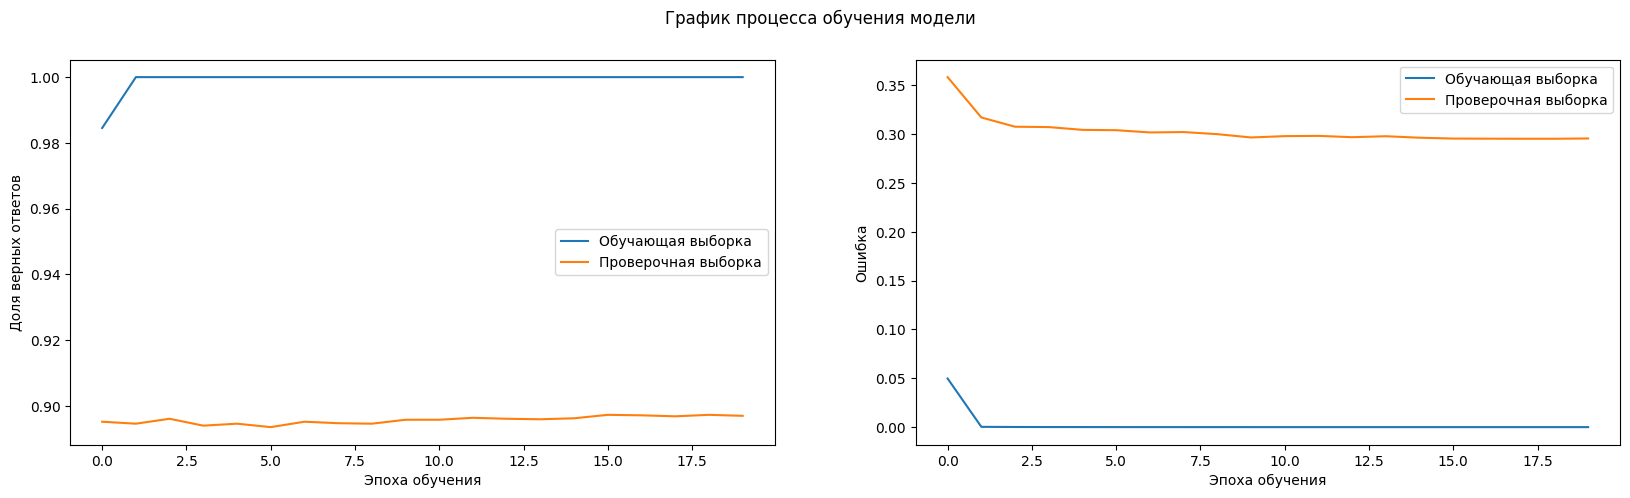

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


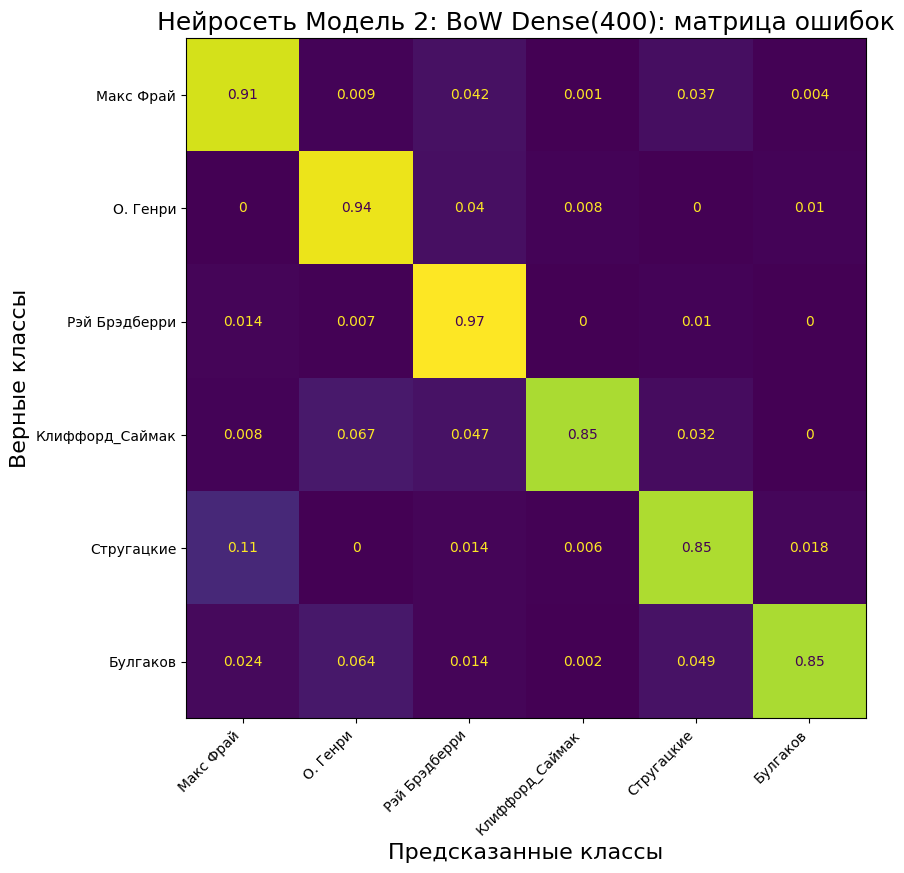

----------------------------------------------------------------------------------------------------
Нейросеть: Модель 2: BoW Dense(400)
Класс: Макс Фрай             91% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              94% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         97% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       85% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            85% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              85% сеть отнесла к классу Булгаков             - ВЕРНО :-)

Средняя точность распознавания:  89%


In [ ]:
model_2 = Sequential()
model_2.add(Dense(400, input_dim=VOCAB_SIZE, activation='relu'))
model_2.add(Dropout(0.4))
model_2.add(BatchNormalization())
model_2.add(Dense(CLASS_COUNT, activation='softmax'))

acc_2 = compile_train_eval_model(model_2, x_train_01, y_train, x_test_01, y_test,
                                 title='Модель 2: BoW Dense(400)')
results['Модель 2: BoW Dense(400)'] = acc_2

## Модель 3: BoW + Dense(300→100)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 300)            │     4,500,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 300)            │         1,200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 6)              │           606 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,532,606 (17.29 MB)

 Trainable params: 4,531,806 (17.29 MB)

 Non-trainable params: 800 (3.12 KB)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.9691 - loss: 0.1073 - val_accuracy: 0.9055 - val_loss: 0.3709
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9999 - loss: 0.0038 - val_accuracy: 0.9121 - val_loss: 0.2906
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.9124 - val_loss: 0.2725
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.9101 - val_loss: 0.2682
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 8.0786e-04 - val_accuracy: 0.9141 - val_loss: 0.2588
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 6.2281e-04 - val_accuracy: 0.9133 - val_loss: 0.2553
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 1.0000 - loss: 4.3379e-04 - val_accuracy: 0.9147 - val_loss: 0.2528
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 1.0000 - loss: 3.559

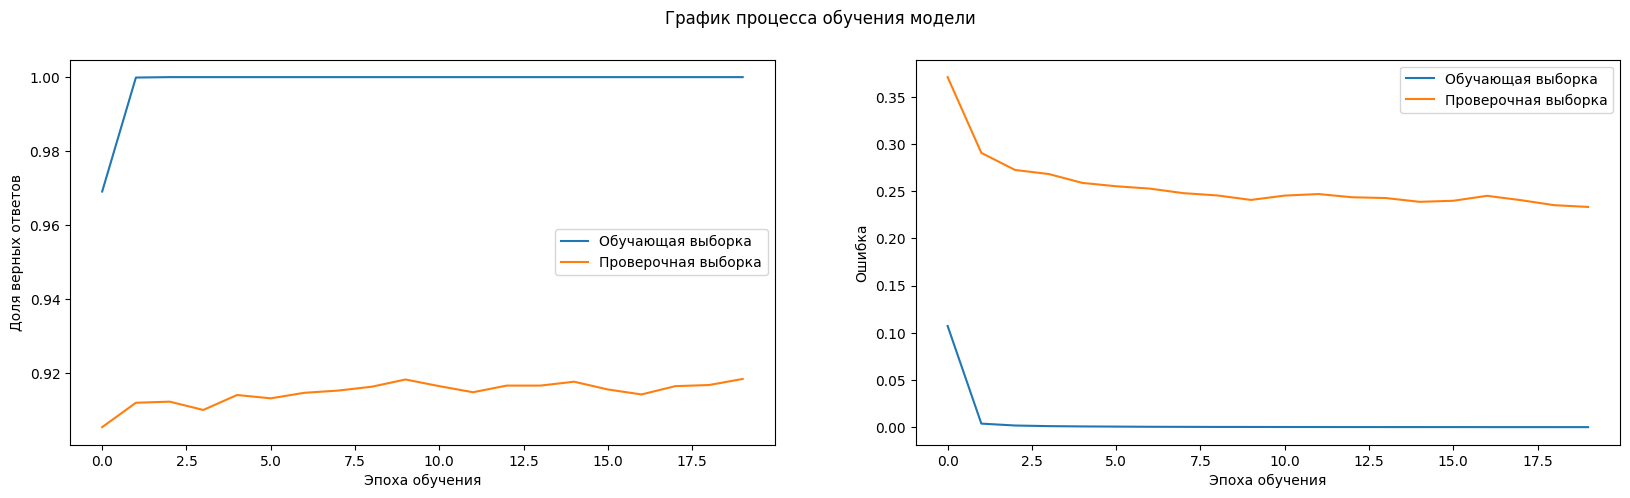

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


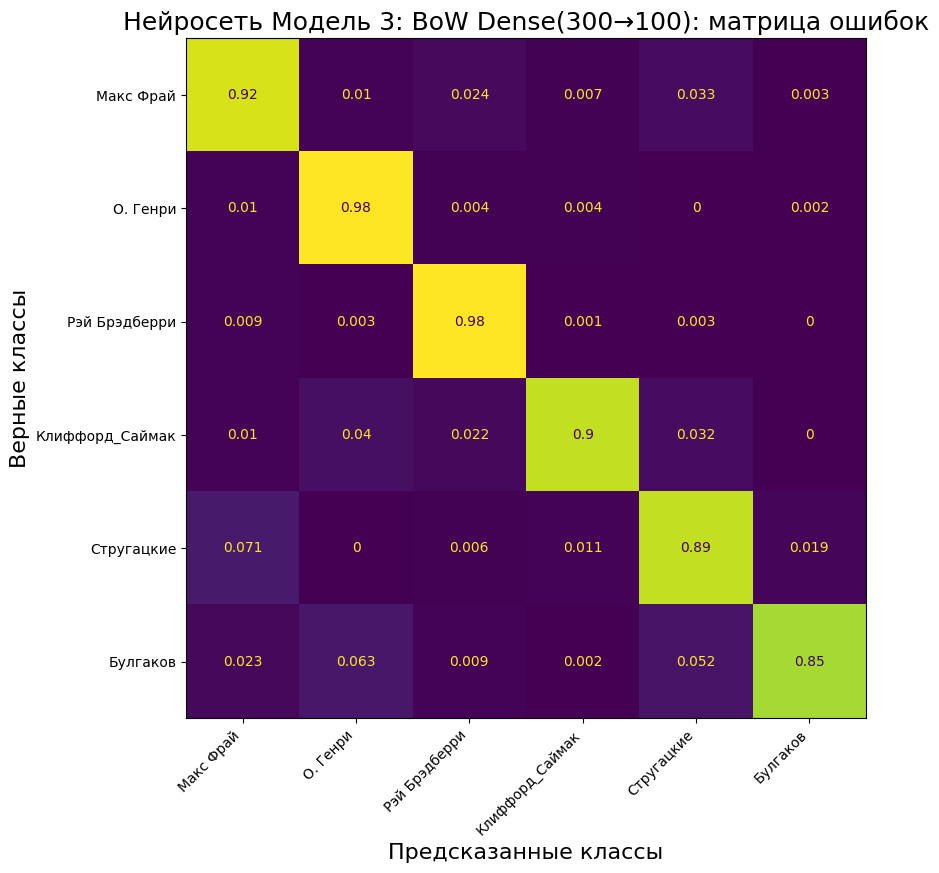

----------------------------------------------------------------------------------------------------
Нейросеть: Модель 3: BoW Dense(300→100)
Класс: Макс Фрай             92% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              98% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         98% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       90% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            89% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              85% сеть отнесла к классу Булгаков             - ВЕРНО :-)

Средняя точность распознавания:  92%


In [ ]:
model_3 = Sequential()
model_3.add(Dense(300, input_dim=VOCAB_SIZE, activation='relu'))
model_3.add(Dropout(0.3))
model_3.add(BatchNormalization())
model_3.add(Dense(100, activation='relu'))
model_3.add(Dropout(0.3))
model_3.add(BatchNormalization())
model_3.add(Dense(CLASS_COUNT, activation='softmax'))

acc_3 = compile_train_eval_model(model_3, x_train_01, y_train, x_test_01, y_test,
                                 title='Модель 3: BoW Dense(300→100)')
results['Модель 3: BoW Dense(300→100)'] = acc_3

## Модель 4: BoW + Dense(500→200→50)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 500)            │     7,500,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 500)            │         2,000 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 200)            │       100,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 200)            │           800 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 50)             │        10,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 50)             │           200 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 6)              │           306 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,614,056 (29.05 MB)

 Trainable params: 7,612,556 (29.04 MB)

 Non-trainable params: 1,500 (5.86 KB)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 14s 52ms/step - accuracy: 0.9575 - loss: 0.1677 - val_accuracy: 0.8750 - val_loss: 0.4163
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9999 - loss: 0.0104 - val_accuracy: 0.8863 - val_loss: 0.3415
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - accuracy: 1.0000 - loss: 0.0048 - val_accuracy: 0.8772 - val_loss: 0.3609
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0030 - val_accuracy: 0.8762 - val_loss: 0.3619
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0021 - val_accuracy: 0.8835 - val_loss: 0.3496
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 0.0014 - val_accuracy: 0.8847 - val_loss: 0.3470
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.8802 - val_loss: 0.3621
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 8.8423e-04 - val

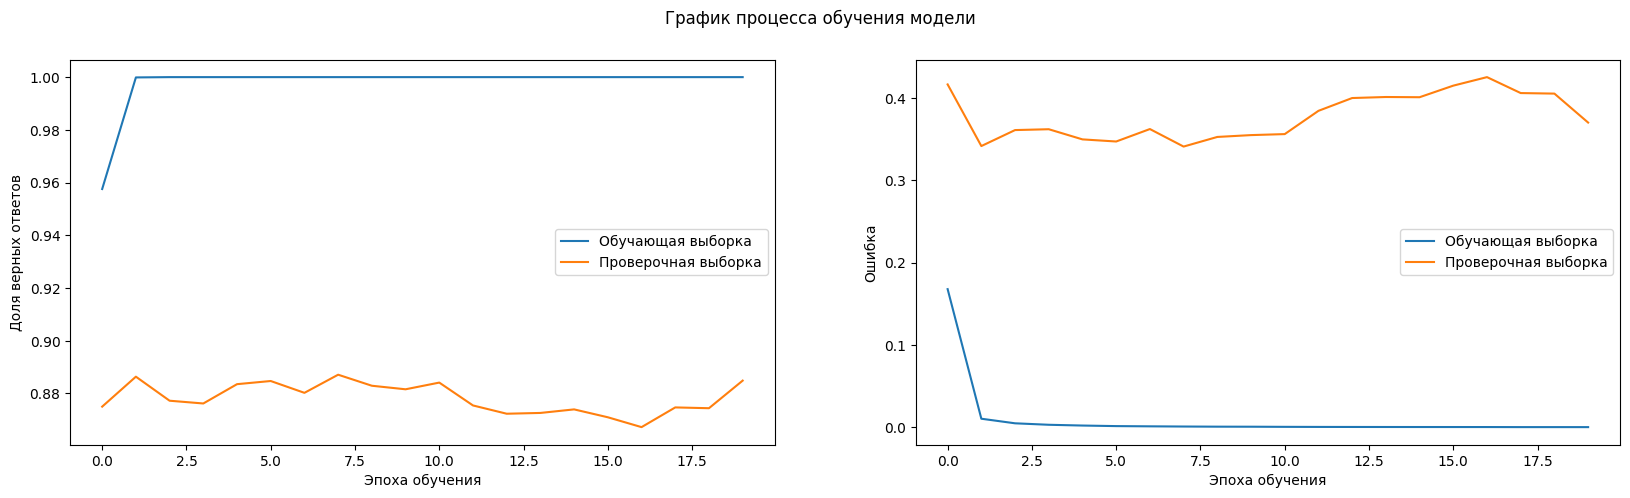

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


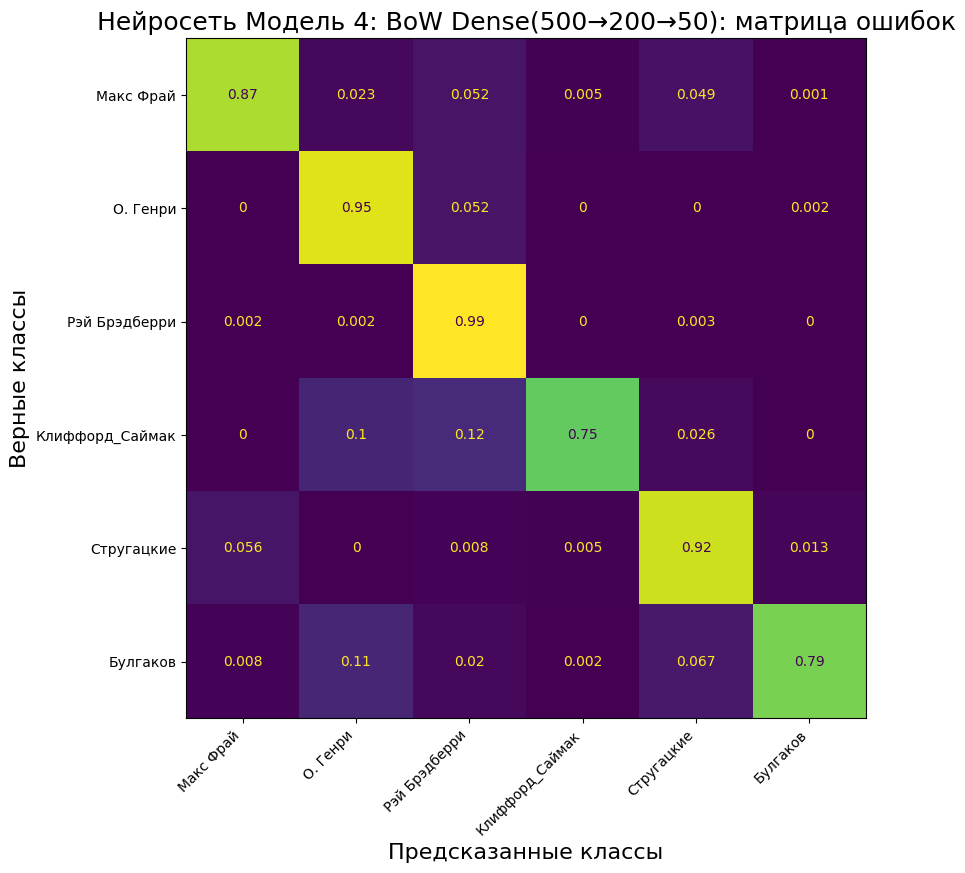

----------------------------------------------------------------------------------------------------
Нейросеть: Модель 4: BoW Dense(500→200→50)
Класс: Макс Фрай             87% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              95% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         99% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       75% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            92% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              79% сеть отнесла к классу Булгаков             - ВЕРНО :-)

Средняя точность распознавания:  88%


In [ ]:
model_4 = Sequential()
model_4.add(Dense(500, input_dim=VOCAB_SIZE, activation='relu'))
model_4.add(Dropout(0.3))
model_4.add(BatchNormalization())
model_4.add(Dense(200, activation='relu'))
model_4.add(Dropout(0.3))
model_4.add(BatchNormalization())
model_4.add(Dense(50, activation='relu'))
model_4.add(Dropout(0.2))
model_4.add(BatchNormalization())
model_4.add(Dense(CLASS_COUNT, activation='softmax'))

acc_4 = compile_train_eval_model(model_4, x_train_01, y_train, x_test_01, y_test,
                                 title='Модель 4: BoW Dense(500→200→50)')
results['Модель 4: BoW Dense(500→200→50)'] = acc_4

## Модель 5: Embedding(20) + Flatten + Dense(200)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - accuracy: 0.7515 - loss: 0.7777 - val_accuracy: 0.3289 - val_loss: 1.7662
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9988 - loss: 0.0160 - val_accuracy: 0.3406 - val_loss: 1.6355
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9997 - loss: 0.0067 - val_accuracy: 0.5503 - val_loss: 1.1743
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9997 - loss: 0.0049 - val_accuracy: 0.6022 - val_loss: 1.1312
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0031 - val_accuracy: 0.6995 - val_loss: 0.8823
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0021 - val_accuracy: 0.7155 - val_loss: 0.8537
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9998 - loss: 0.0018 - val_accuracy: 0.7028 - val_loss: 0.9110
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9999 - loss: 0.0016 - val_accuracy: 

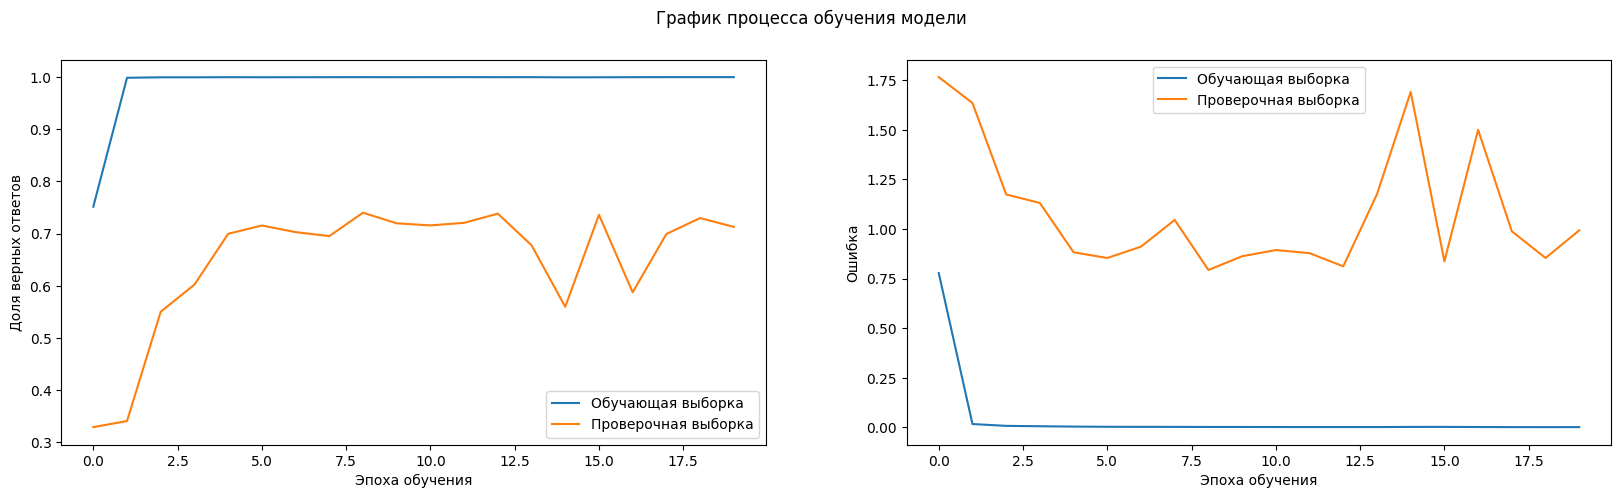

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


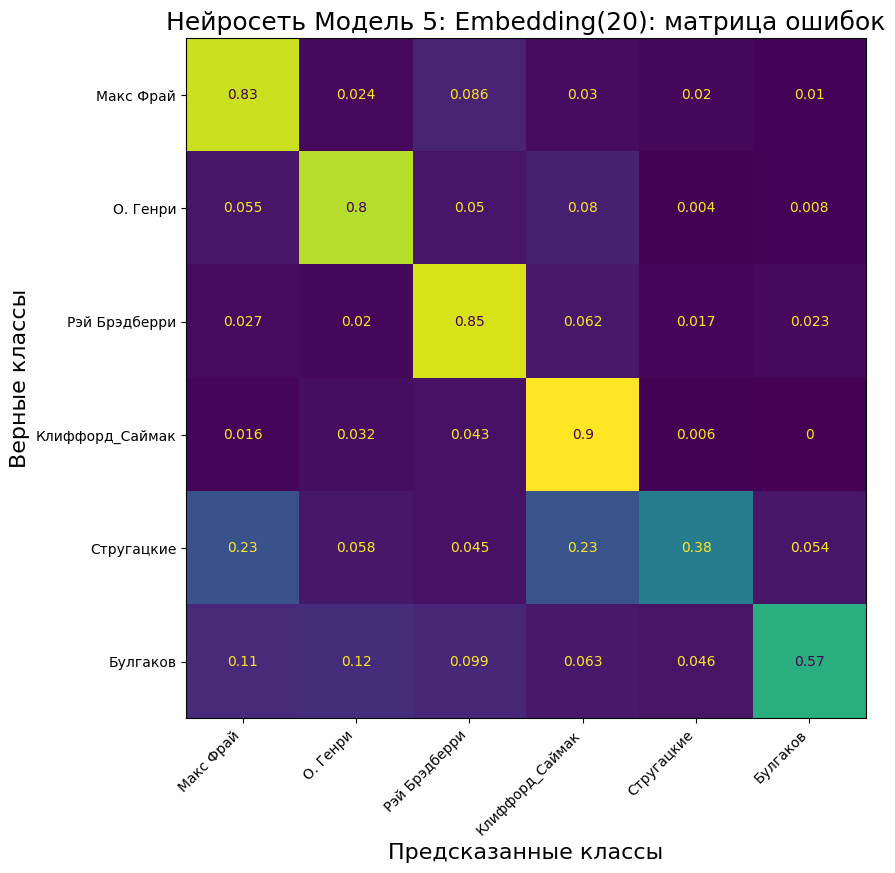

----------------------------------------------------------------------------------------------------
Нейросеть: Модель 5: Embedding(20)
Класс: Макс Фрай             83% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              80% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         85% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       90% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            38% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              57% сеть отнесла к классу Булгаков             - ВЕРНО :-)

Средняя точность распознавания:  72%


In [ ]:
model_5 = Sequential()
model_5.add(Embedding(input_dim=VOCAB_SIZE, output_dim=20, input_length=WIN_SIZE))
model_5.add(SpatialDropout1D(0.2))
model_5.add(Flatten())
model_5.add(BatchNormalization())
model_5.add(Dense(200, activation='relu'))
model_5.add(Dropout(0.2))
model_5.add(BatchNormalization())
model_5.add(Dense(CLASS_COUNT, activation='softmax'))

acc_5 = compile_train_eval_model(model_5, x_train, y_train, x_test, y_test,
                                 title='Модель 5: Embedding(20)')
results['Модель 5: Embedding(20) + Flatten'] = acc_5

## Модель 6: Embedding(50) + Flatten + Dense(300)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 12s 47ms/step - accuracy: 0.7689 - loss: 0.7879 - val_accuracy: 0.3015 - val_loss: 1.7548
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9995 - loss: 0.0127 - val_accuracy: 0.3599 - val_loss: 1.4948
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9999 - loss: 0.0053 - val_accuracy: 0.5229 - val_loss: 1.1841
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9999 - loss: 0.0031 - val_accuracy: 0.6575 - val_loss: 0.9356
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9998 - loss: 0.0023 - val_accuracy: 0.6787 - val_loss: 0.8972
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.6992 - val_loss: 0.8687
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 1.0000 - loss: 0.0012 - val_accuracy: 0.7182 - val_loss: 0.8450
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.9999 - loss: 9.5576e-04 - val

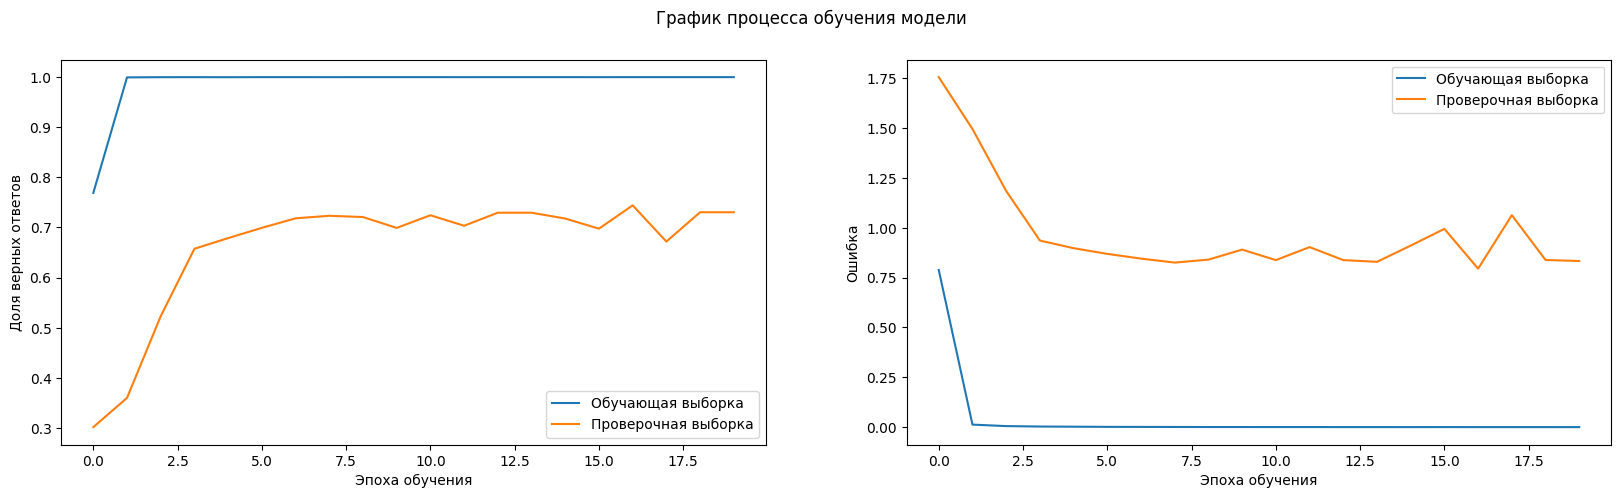

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


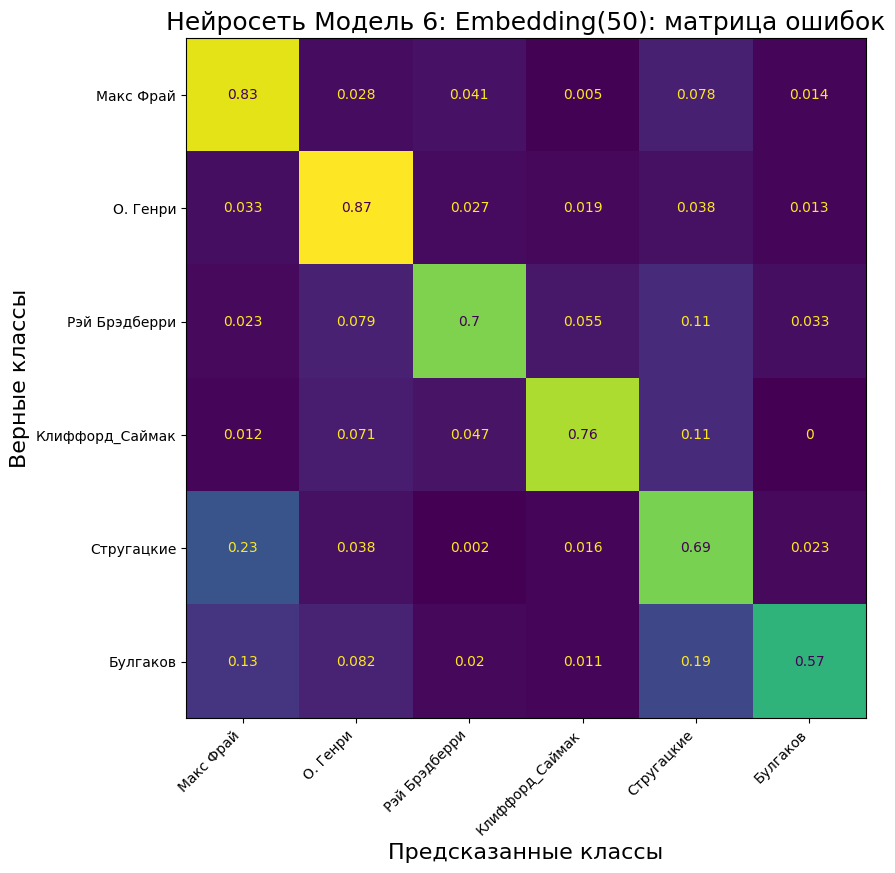

----------------------------------------------------------------------------------------------------
Нейросеть: Модель 6: Embedding(50)
Класс: Макс Фрай             83% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              87% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         70% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       76% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            70% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              57% сеть отнесла к классу Булгаков             - ВЕРНО :-)

Средняя точность распознавания:  74%


In [ ]:
model_6 = Sequential()
model_6.add(Embedding(input_dim=VOCAB_SIZE, output_dim=50, input_length=WIN_SIZE))
model_6.add(SpatialDropout1D(0.3))
model_6.add(Flatten())
model_6.add(BatchNormalization())
model_6.add(Dense(300, activation='relu'))
model_6.add(Dropout(0.3))
model_6.add(BatchNormalization())
model_6.add(Dense(CLASS_COUNT, activation='softmax'))

acc_6 = compile_train_eval_model(model_6, x_train, y_train, x_test, y_test,
                                 title='Модель 6: Embedding(50)')
results['Модель 6: Embedding(50) + Flatten'] = acc_6

## Модель 7: Embedding(100) + Flatten + Dense(200→100)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - accuracy: 0.7386 - loss: 0.7696 - val_accuracy: 0.3498 - val_loss: 1.8828
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9984 - loss: 0.0253 - val_accuracy: 0.4358 - val_loss: 1.4810
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9999 - loss: 0.0078 - val_accuracy: 0.5821 - val_loss: 1.1348
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 1.0000 - loss: 0.0042 - val_accuracy: 0.6820 - val_loss: 0.8866
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.7456 - val_loss: 0.7541
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.9999 - loss: 0.0020 - val_accuracy: 0.7692 - val_loss: 0.7038
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.9999 - loss: 0.0014 - val_accuracy: 0.7540 - val_loss: 0.7436
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.9999 - loss: 0.0011 - val_acc

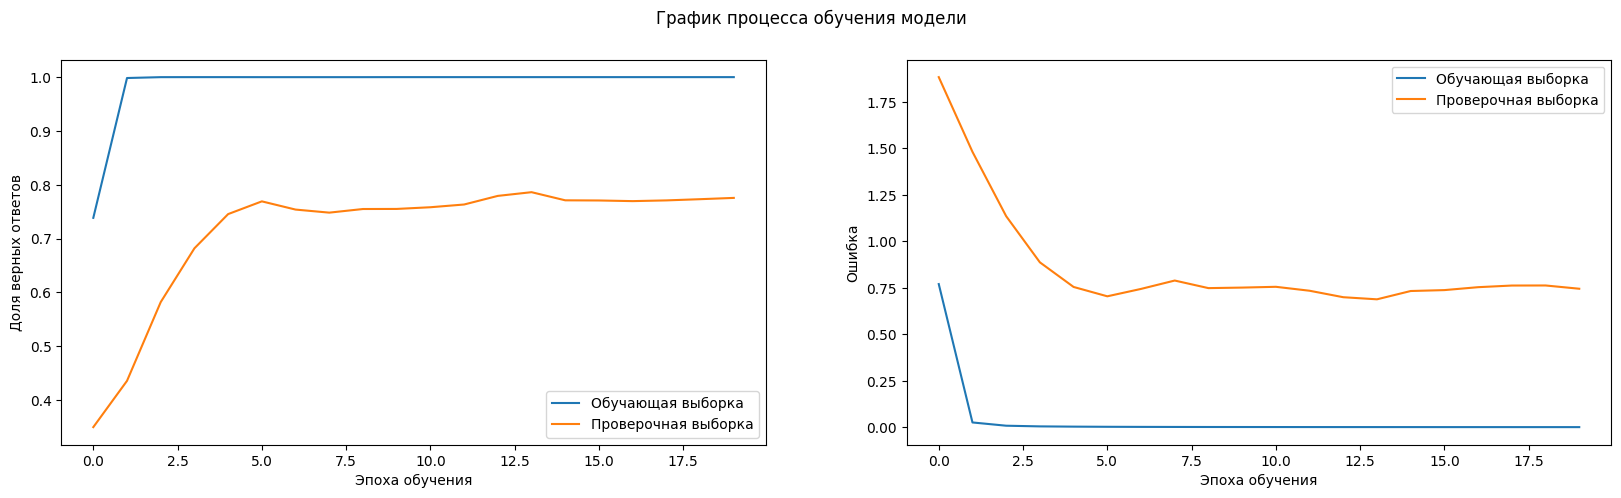

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


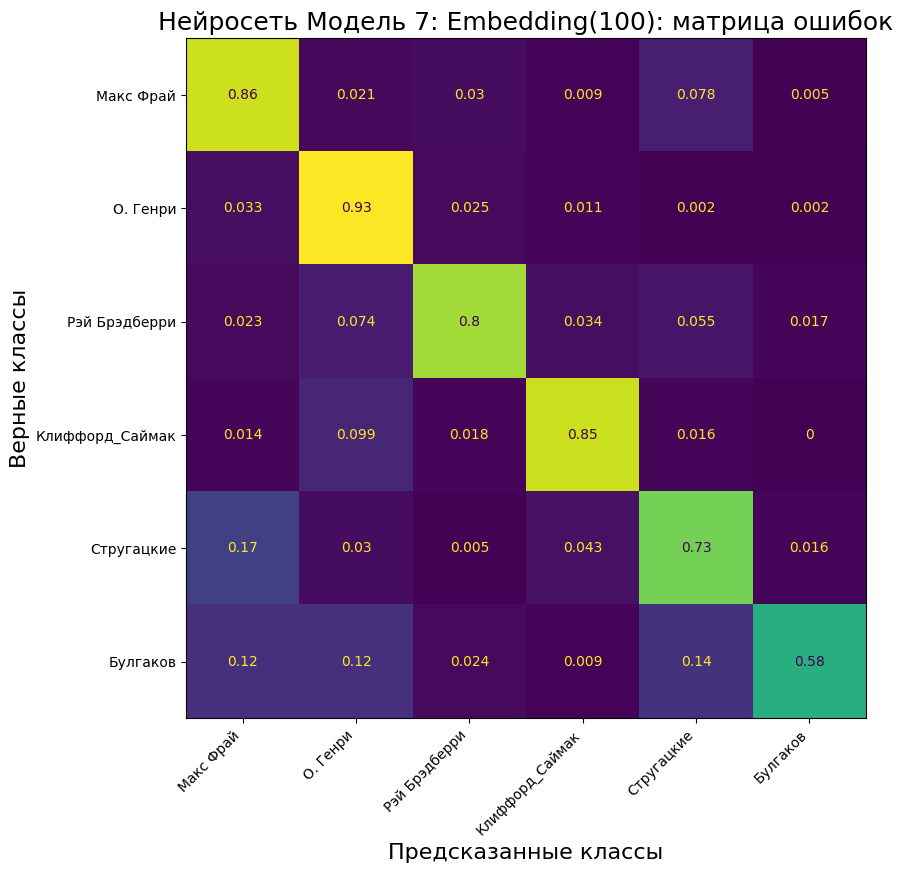

----------------------------------------------------------------------------------------------------
Нейросеть: Модель 7: Embedding(100)
Класс: Макс Фрай             86% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              93% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         80% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       85% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            73% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              58% сеть отнесла к классу Булгаков             - ВЕРНО :-)

Средняя точность распознавания:  79%


In [ ]:
model_7 = Sequential()
model_7.add(Embedding(input_dim=VOCAB_SIZE, output_dim=100, input_length=WIN_SIZE))
model_7.add(SpatialDropout1D(0.2))
model_7.add(Flatten())
model_7.add(BatchNormalization())
model_7.add(Dense(200, activation='relu'))
model_7.add(Dropout(0.3))
model_7.add(BatchNormalization())
model_7.add(Dense(100, activation='relu'))
model_7.add(Dropout(0.2))
model_7.add(BatchNormalization())
model_7.add(Dense(CLASS_COUNT, activation='softmax'))

acc_7 = compile_train_eval_model(model_7, x_train, y_train, x_test, y_test,
                                 title='Модель 7: Embedding(100)')
results['Модель 7: Embedding(100) + Flatten'] = acc_7

## Модель 8: Embedding(200) + Flatten + Dense(200) + Dropout(0.5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_3             │ ?                      │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_15          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 16s 66ms/step - accuracy: 0.7849 - loss: 0.6928 - val_accuracy: 0.3003 - val_loss: 1.8475
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9997 - loss: 0.0197 - val_accuracy: 0.3774 - val_loss: 1.3834
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 0.9999 - loss: 0.0074 - val_accuracy: 0.5378 - val_loss: 1.1399
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.7235 - val_loss: 0.8216
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 1.0000 - loss: 0.0028 - val_accuracy: 0.7583 - val_loss: 0.7068
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.7570 - val_loss: 0.6958
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 1.0000 - loss: 0.0015 - val_accuracy: 0.7638 - val_loss: 0.6803
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 1.0000 - loss: 0.0012 - val_acc

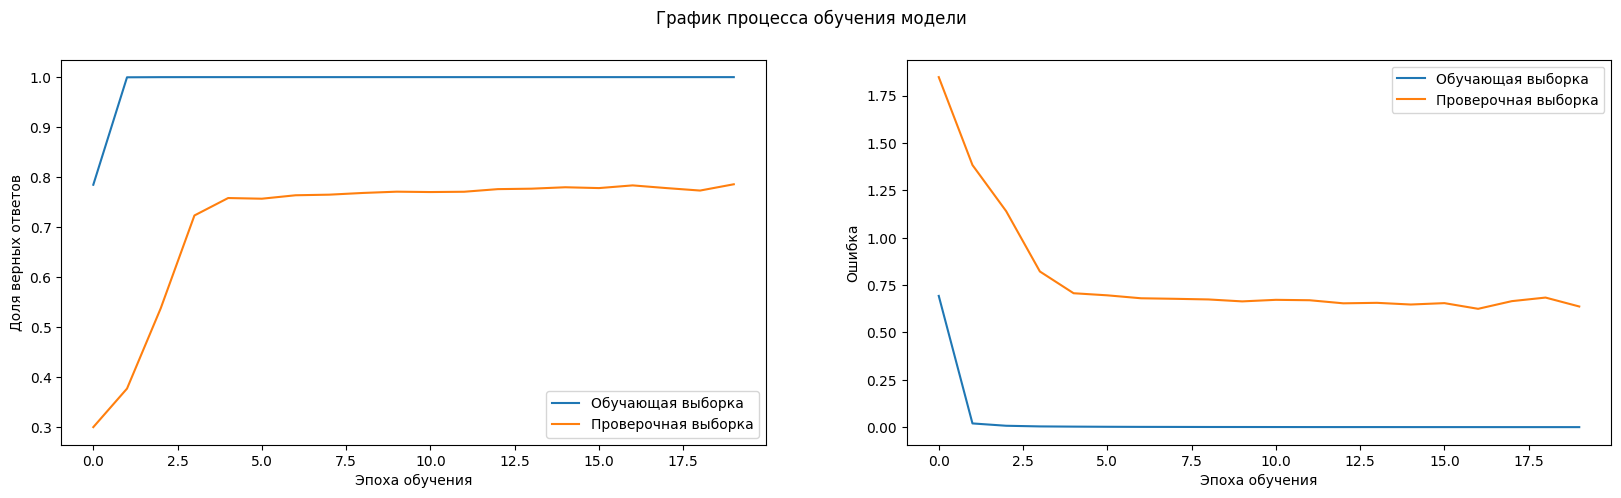

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


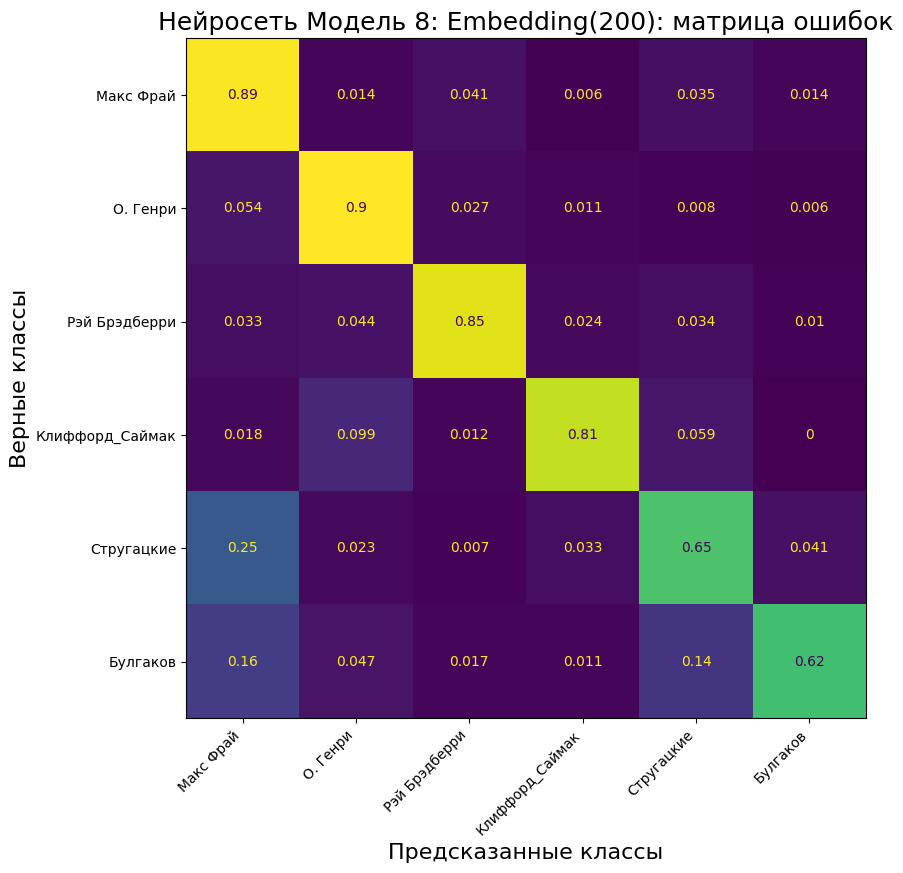

----------------------------------------------------------------------------------------------------
Нейросеть: Модель 8: Embedding(200)
Класс: Макс Фрай             89% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              90% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         86% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       81% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            64% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              62% сеть отнесла к классу Булгаков             - ВЕРНО :-)

Средняя точность распознавания:  79%


In [ ]:
model_8 = Sequential()
model_8.add(Embedding(input_dim=VOCAB_SIZE, output_dim=200, input_length=WIN_SIZE))
model_8.add(SpatialDropout1D(0.4))
model_8.add(Flatten())
model_8.add(BatchNormalization())
model_8.add(Dense(200, activation='relu'))
model_8.add(Dropout(0.5))
model_8.add(BatchNormalization())
model_8.add(Dense(CLASS_COUNT, activation='softmax'))

acc_8 = compile_train_eval_model(model_8, x_train, y_train, x_test, y_test,
                                 title='Модель 8: Embedding(200)')
results['Модель 8: Embedding(200) + Dropout(0.5)'] = acc_8

## Модель 9: Embedding(200) + Flatten без регуляризации Dropout

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_4 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_17          │ ?                      │   0 (unbuilt) │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 10s 46ms/step - accuracy: 0.8685 - loss: 0.5617 - val_accuracy: 0.0784 - val_loss: 2.0236
Epoch 2/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.4104 - val_loss: 1.5016
Epoch 3/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 1.0000 - loss: 0.0020 - val_accuracy: 0.5673 - val_loss: 1.2085
Epoch 4/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 29ms/step - accuracy: 1.0000 - loss: 0.0011 - val_accuracy: 0.6642 - val_loss: 0.9836
Epoch 5/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 1.0000 - loss: 7.0730e-04 - val_accuracy: 0.6947 - val_loss: 0.9157
Epoch 6/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 1.0000 - loss: 5.0710e-04 - val_accuracy: 0.7066 - val_loss: 0.9190
Epoch 7/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 1.0000 - loss: 4.1693e-04 - val_accuracy: 0.7095 - val_loss: 0.9306
Epoch 8/20
138/138 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 1.0000 - loss: 2.83

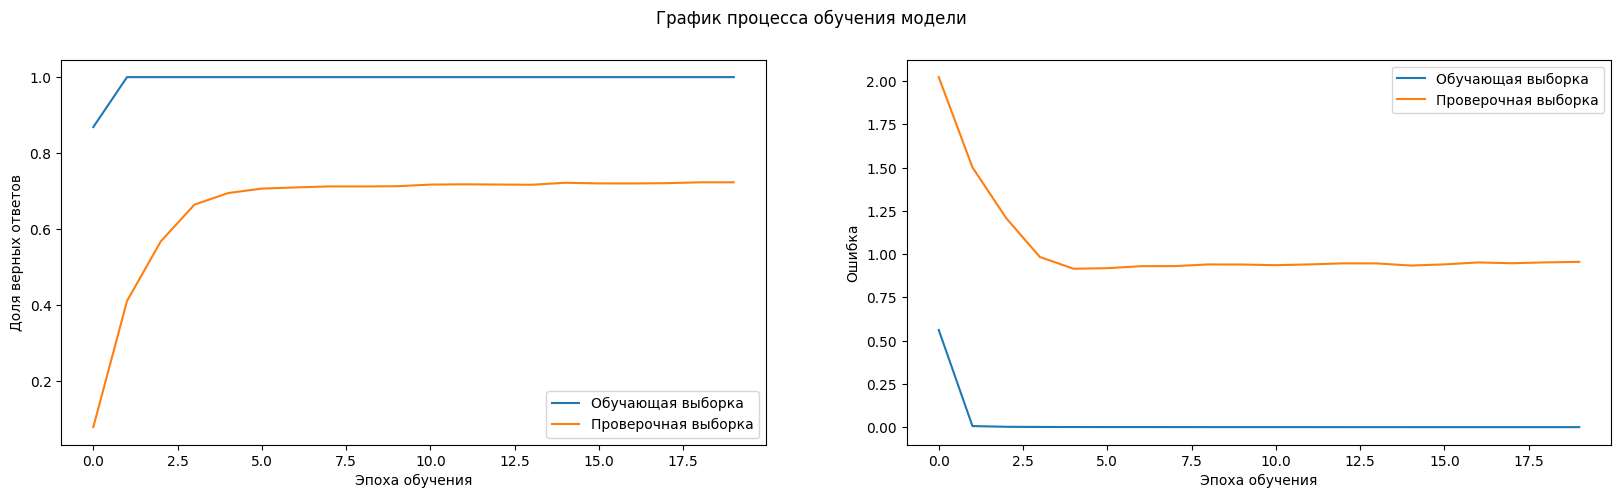

209/209 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


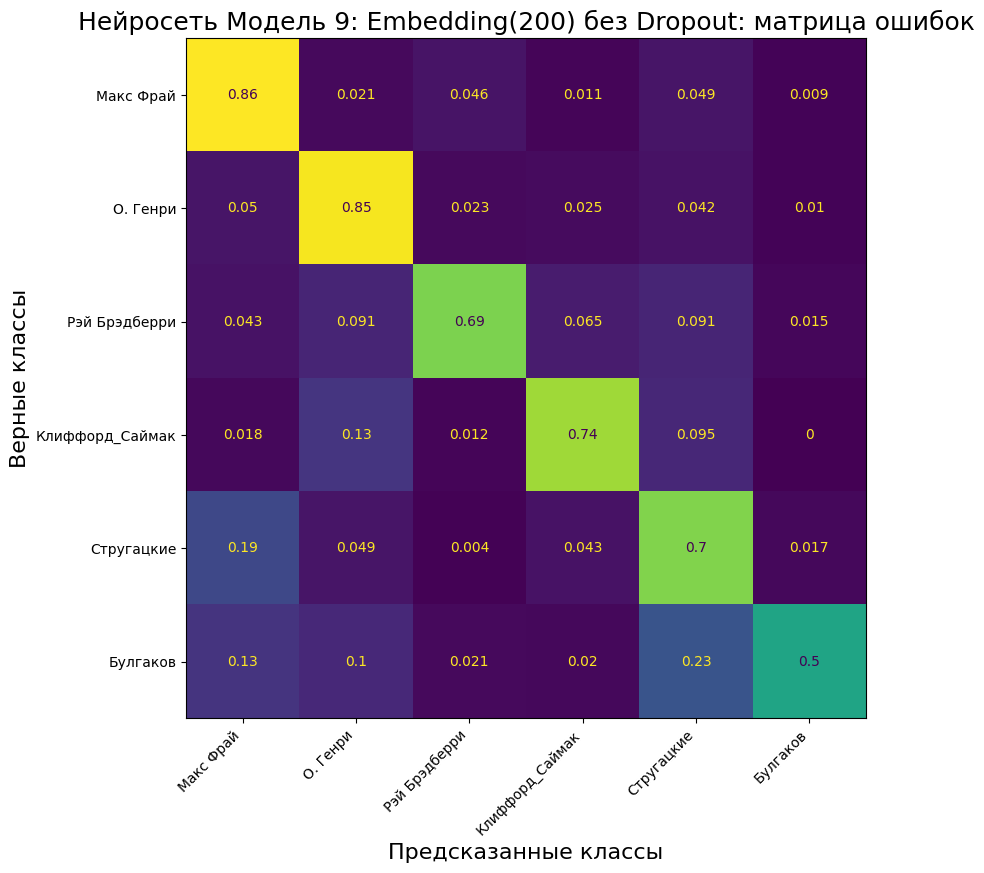

----------------------------------------------------------------------------------------------------
Нейросеть: Модель 9: Embedding(200) без Dropout
Класс: Макс Фрай             86% сеть отнесла к классу Макс Фрай            - ВЕРНО :-)
Класс: О. Генри              85% сеть отнесла к классу О. Генри             - ВЕРНО :-)
Класс: Рэй Брэдберри         70% сеть отнесла к классу Рэй Брэдберри        - ВЕРНО :-)
Класс: Клиффорд_Саймак       74% сеть отнесла к классу Клиффорд_Саймак      - ВЕРНО :-)
Класс: Стругацкие            70% сеть отнесла к классу Стругацкие           - ВЕРНО :-)
Класс: Булгаков              50% сеть отнесла к классу Булгаков             - ВЕРНО :-)

Средняя точность распознавания:  73%


In [ ]:
model_9 = Sequential()
model_9.add(Embedding(input_dim=VOCAB_SIZE, output_dim=200, input_length=WIN_SIZE))
model_9.add(Flatten())
model_9.add(BatchNormalization())
model_9.add(Dense(200, activation='relu'))
model_9.add(BatchNormalization())
model_9.add(Dense(CLASS_COUNT, activation='softmax'))

acc_9 = compile_train_eval_model(model_9, x_train, y_train, x_test, y_test,
                                 title='Модель 9: Embedding(200) без Dropout')
results['Модель 9: Embedding(200) без Dropout'] = acc_9

# Итоги

In [ ]:
print('СВОДНАЯ ТАБЛИЦА ТОЧНОСТИ')
for name, acc in results.items():
    print(f'{name:<50} → {acc:5.1f}%')

best_name = max(results, key=results.get)
print(f'\n Лучшая модель: {best_name}')
print(f'   Точность: {results[best_name]:.1f}%')

СВОДНАЯ ТАБЛИЦА ТОЧНОСТИ
Модель 1: BoW Dense(200)                           →  90.5%
Модель 2: BoW Dense(400)                           →  89.4%
Модель 3: BoW Dense(300→100)                       →  92.1%
Модель 4: BoW Dense(500→200→50)                    →  87.9%
Модель 5: Embedding(20) + Flatten                  →  72.2%
Модель 6: Embedding(50) + Flatten                  →  73.9%
Модель 7: Embedding(100) + Flatten                 →  79.1%
Модель 8: Embedding(200) + Dropout(0.5)            →  78.7%
Модель 9: Embedding(200) без Dropout               →  72.6%

 Лучшая модель: Модель 3: BoW Dense(300→100)
   Точность: 92.1%


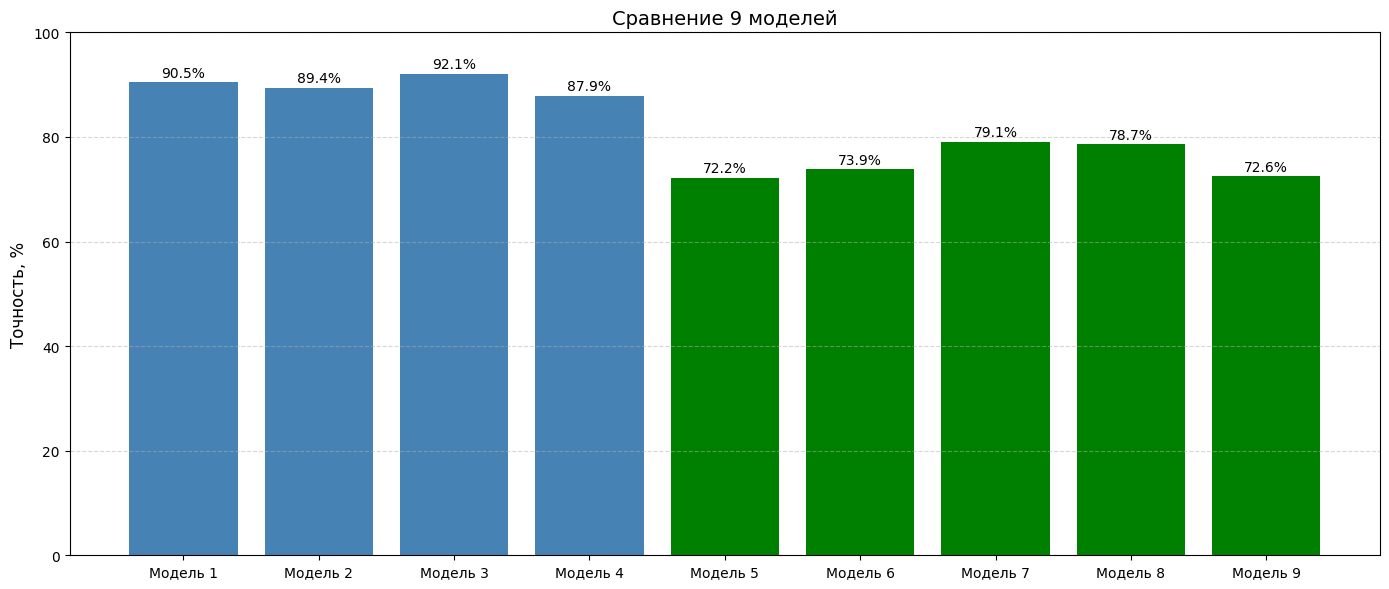

In [ ]:
fig, ax = plt.subplots(figsize=(14, 6))
short_names = [f'Модель {i+1}' for i in range(len(results))]
values = list(results.values())
colors = ['steelblue']*4 + ['green']*5

bars = ax.bar(short_names, values, color=colors)
ax.set_ylabel('Точность, %', fontsize=12)
ax.set_title('Сравнение 9 моделей', fontsize=14)
ax.set_ylim(0, 100)
ax.grid(axis='y', linestyle='--', alpha=0.5)

for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{val:.1f}%', ha='center', fontsize=10)

plt.xticks(rotation=0)
plt.tight_layout()
plt.show()